In [1]:
pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.8/41.9 MB 9.0 MB/s eta 0:00:05
   -- ------------------------------------- 2.9/41.9 MB 6.8 MB/s eta 0:00:06
   ---- ----------------------------------- 4.5/41.9 MB 7.0 MB/s eta 0:00:06
   ----- ---------------------------------- 5.8/41.9 MB 6.7 MB/s eta 0:00:06
   ------ --------------------------------- 7.1/41.9 MB 6.7 MB/s eta 0:00:06
   -------- ------------------------------- 8.4/41.9 MB 6.5 MB/s eta


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

c:\Users\Aditya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/processed/loan_feature_engineered.csv")

X = df.drop(columns=["default"])
y = df["default"]

print("X shape:", X.shape)

X shape: (1303638, 92)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_test shape:", X_test.shape)

X_test shape: (260728, 92)


In [6]:
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [9]:
xgb_model = joblib.load("../models/xgboost.pkl")

print("XGBoost loaded successfully!")

XGBoost loaded successfully!


In [10]:
X_shap = X_test_scaled[:2000]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 92)


In [11]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP calculation completed!")

SHAP calculation completed!


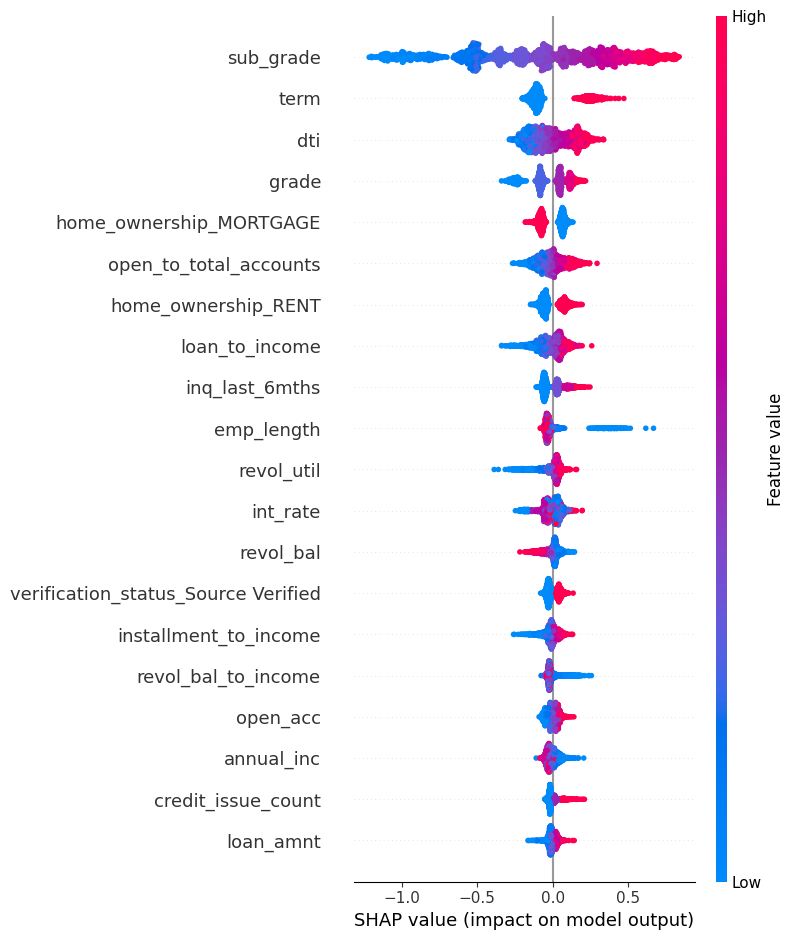

In [12]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns
)

In [13]:
loan_index = 0

single_loan = X_shap[loan_index:loan_index+1]

single_shap_values = explainer.shap_values(single_loan)

print("Single loan SHAP calculated!")

Single loan SHAP calculated!


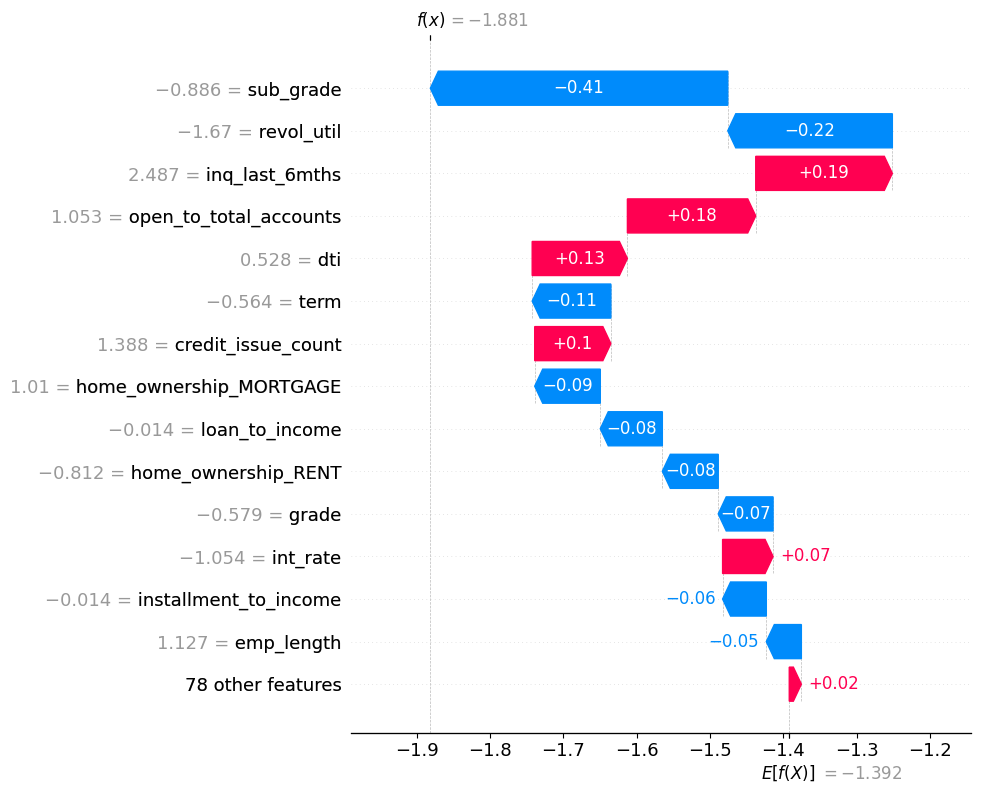

In [14]:
shap.plots.waterfall(
    shap.Explanation(
        values=single_shap_values[0],
        base_values=explainer.expected_value,
        data=single_loan[0],
        feature_names=X.columns
    ),
    max_display=15
)

In [15]:
plt.savefig(
    "../screenshots/shap_waterfall.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

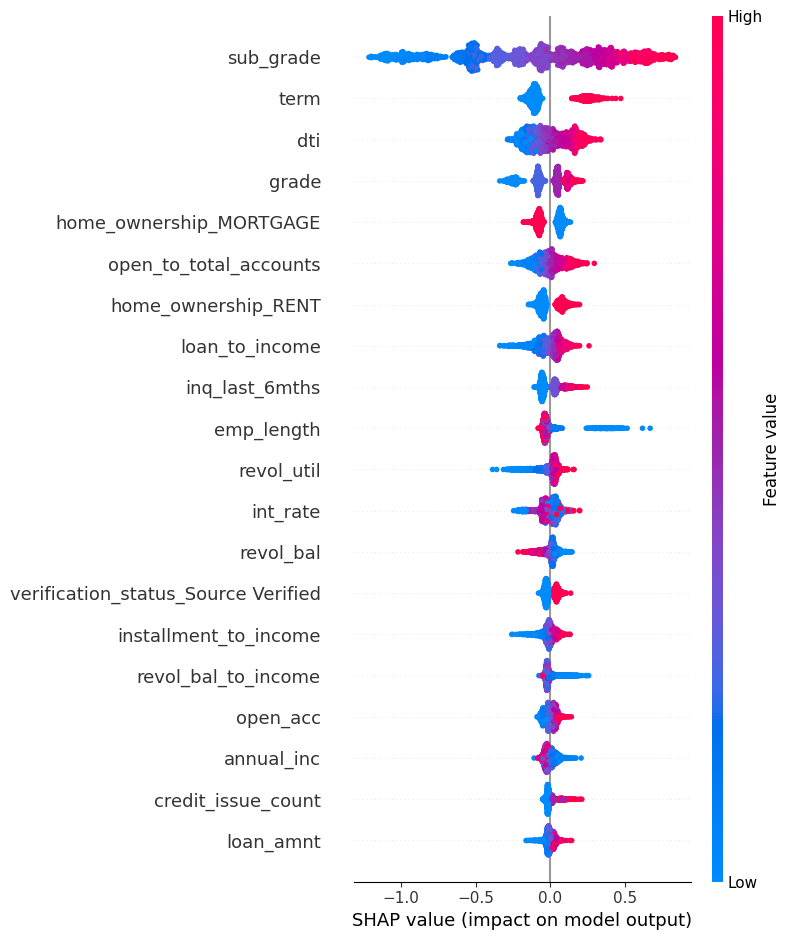

In [16]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns,
    max_display=20,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../screenshots/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [17]:
loan_index = 0

single_loan = X_shap[loan_index:loan_index+1]

single_shap_values = explainer.shap_values(single_loan)

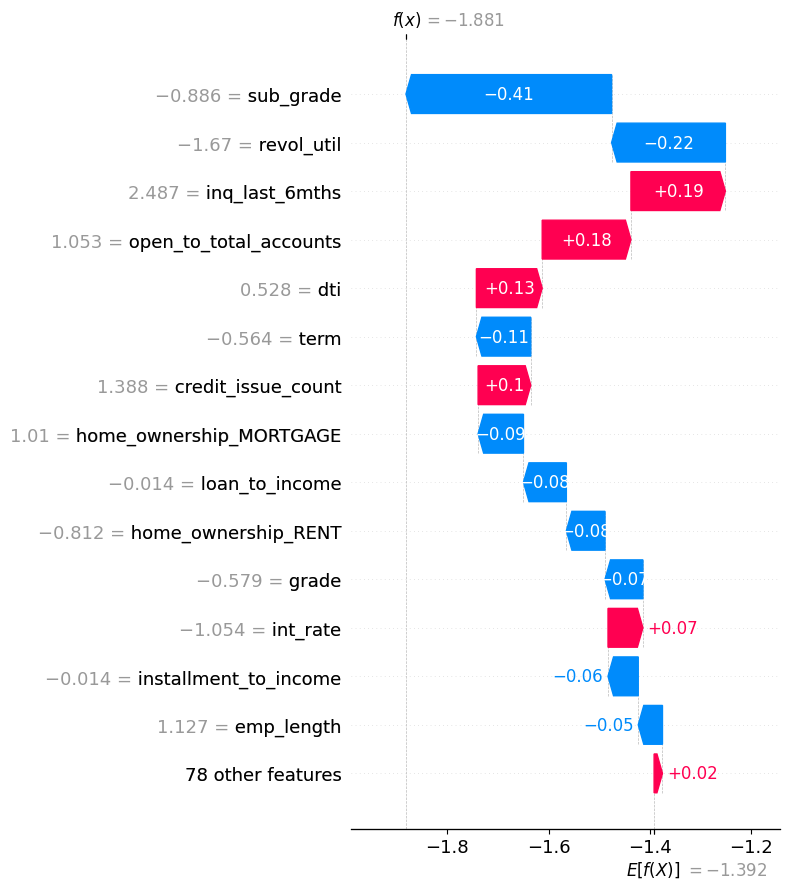

In [18]:
shap.plots.waterfall(
    shap.Explanation(
        values=single_shap_values[0],
        base_values=explainer.expected_value,
        data=single_loan[0],
        feature_names=X.columns
    ),
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../screenshots/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()